In [1]:
%load_ext autoreload
%autoreload 2

import sys
import featuregraph as fg

print("Python:", sys.executable)
print("FeatureGraph:", fg.__file__)

Python: /usr/local/bin/python
FeatureGraph: /workspaces/featuregraph/src/featuregraph/__init__.py


In [2]:
eastman = fg.datasets.eastman(
    fault_number=1,
    simulation_run=1,
)

bidmc = fg.datasets.bidmc(
    subject=1,
)


eastman_oscillation = fg.oscillation.Oscillation(
    signals="reactor_temperature",
    group=["fault_number", "simulation_run"],
    smooth_signal=True,
    smooth_window=20,
)

eastman_features = eastman_oscillation.fit_transform(
    eastman
)

eastman_objects = eastman_oscillation.summarize(
    eastman_features,
    signal="reactor_temperature",
)


bidmc_oscillation = fg.oscillation.Oscillation(
    signals="respiration",
    group="subject",
    smooth_signal=False,
)

bidmc_features = bidmc_oscillation.fit_transform(
    bidmc
)

bidmc_objects = bidmc_oscillation.summarize(
    bidmc_features,
    signal="respiration",
)

In [3]:
bidmc_objects

,subject,oscillation_id,is_complete,start_index,peak_index,end_index,rise_duration,fall_duration,duration,period,amplitude,rising_mean_rate,falling_mean_rate,peak_rise_rate,peak_fall_rate,temporal_symmetry
0,1,1,True,10.0,14.0,80.0,4,66,70,NaN,0.174974,0.087487,0.005302,0.001466,0.011535,0.114286
1,1,2,True,80.0,167.0,254.0,87,87,174,153.0,0.484849,0.011146,0.011146,0.015445,0.019452,1.000000
2,1,3,True,291.0,299.0,365.0,8,66,74,132.0,0.120235,0.030059,0.003643,0.000880,0.007038,0.216216
3,1,4,True,365.0,457.0,519.0,92,62,154,158.0,0.481427,0.010466,0.015530,0.013490,0.026002,0.805195
4,1,5,True,552.0,577.0,642.0,25,65,90,120.0,0.184262,0.014741,0.005670,0.004496,0.010753,0.555556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1,549,True,59444.0,59459.0,59518.0,15,59,74,46.0,0.389050,0.051873,0.013188,0.001760,0.019844,0.405405
541,1,550,True,59525.0,59567.0,59619.0,42,52,94,108.0,0.122188,0.005818,0.004700,0.004887,0.009873,0.893617
542,1,551,True,59620.0,59659.0,59677.0,39,18,57,92.0,0.058160,0.002983,0.006462,0.004985,0.004496,0.631579
543,1,552,True,59677.0,59793.0,59846.0,116,53,169,134.0,0.415445,0.007163,0.015677,0.011535,0.029227,0.627219


In [4]:
eastman_accumulation = fg.accumulation.Accumulation(signals='reactor_temperature', group=["fault_number", "simulation_run"])
eastman_accumulation_features = eastman_accumulation.fit_transform(eastman_features)
eastman_accumulation_objects = eastman_accumulation.summarize(eastman_accumulation_features, signal='reactor_temperature')
eastman_accumulation_objects

,fault_number,simulation_run,accumulation_id,start_index,end_index,duration,baseline,total_auc,auc_at_peak,accumulation_before_peak,accumulation_from_peak,accumulation_rate,accumulation_symmetry,centroid_time,half_accumulation_time
0,1,1,0,0,31,32,122.873796,0.837794,0.000000,0.837794,0.000000,0.026181,0.000000,15.398347,16
1,1,1,1,32,34,3,122.896609,0.015214,0.015214,0.012712,0.002502,0.005071,0.328880,0.328880,0
2,1,1,2,35,39,5,122.896695,0.022736,0.006108,0.003971,0.018766,0.004547,0.349288,2.899176,3
3,1,1,3,40,73,34,122.877444,0.708018,0.298830,0.298830,0.409188,0.020824,0.844130,15.448906,15
4,1,1,4,74,75,2,122.889032,0.013375,0.013375,0.013375,0.000000,0.006688,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,1,1,200,2950,2958,9,122.886063,0.120266,0.066918,0.057916,0.062351,0.013363,0.963123,3.627825,4
201,1,1,201,2959,2976,18,122.876560,0.410987,0.319000,0.311594,0.099393,0.022833,0.483678,7.473886,7
202,1,1,202,2977,2985,9,122.892931,0.091317,0.032482,0.022282,0.069035,0.010146,0.488016,4.403274,5
203,1,1,203,2986,2990,5,122.887807,0.051022,0.018942,0.018942,0.032080,0.010204,0.742503,2.149827,3


In [5]:
bidmc_accumulation = fg.accumulation.Accumulation(signals='respiration', group='subject')
bidmc_accumulation_features = bidmc_accumulation.fit_transform(bidmc_features)
bidmc_accumulation_objects = bidmc_accumulation.summarize(bidmc_accumulation_features, signal='respiration')
bidmc_accumulation_objects

,subject,accumulation_id,start_index,end_index,duration,baseline,total_auc,auc_at_peak,accumulation_before_peak,accumulation_from_peak,accumulation_rate,accumulation_symmetry,centroid_time,half_accumulation_time
0,1,0,0,9,10,0.353860,0.093840,0.000000,0.093840,0.000000,0.009384,0.000000,5.989344,6
1,1,1,10,79,70,0.018573,9.866038,1.737045,1.393938,8.472100,0.140943,0.282573,18.677637,15
2,1,2,80,290,211,0.030303,121.809414,45.742933,44.773236,77.036178,0.577296,0.735136,105.345667,103
3,1,3,291,364,74,0.019550,9.390079,2.138800,1.906150,7.483929,0.126893,0.405992,24.088458,21
4,1,4,365,551,187,0.037146,107.700804,49.525838,48.562984,59.137820,0.575940,0.901813,96.828786,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,1,550,59525,59619,95,0.096774,11.942353,8.267878,8.030342,3.912011,0.125709,0.655149,32.519312,33
551,1,551,59620,59676,57,0.098729,3.753673,2.547406,2.442815,1.310858,0.065854,0.698440,33.322150,33
552,1,552,59677,59878,202,0.169110,98.348120,54.841690,54.010800,44.337320,0.486872,0.901640,107.061031,110
553,1,553,59879,59963,85,0.126100,11.359690,6.927640,6.677400,4.682290,0.133643,0.824369,26.060680,25


In [6]:
# transition_id
# parent_oscillation_id
# direction = "rising"
# start_index
# end_index
# duration
# start_value
# end_value
# net_change
# mean_rate
# peak_rate

In [7]:
bidmc_features['respiration_rising_id'] = bidmc_features[bidmc_features['respiration_rising'] == 1]['enter_respiration_rising'].cumsum()
bidmc_features['respiration_rising_duration'] = bidmc_features[bidmc_features['respiration_rising'] == 1]['respiration_rising_time']
bidmc_features['maximum'] = bidmc_features.groupby('respiration_rising_id')['respiration'].transform('last')
bidmc_features['minimum'] = bidmc_features.groupby('respiration_rising_id')['respiration'].transform('first')
bidmc_features['respiration_rising_mean_rate'] = (bidmc_features['maximum'] - bidmc_features['minimum']) / bidmc_features['respiration_rising_time']
bidmc_features['respiration_rising_change_rate'] = bidmc_features['respiration'].diff()
bidmc_features['respiration_rising_peak_rate'] = bidmc_features.groupby('respiration_rising_id')['respiration_rising_change_rate'].transform('max')


(<Figure size 1600x880 with 4 Axes>,
 array([<Axes: ylabel='respiration'>,
        <Axes: ylabel='respiration_rising_duration'>,
        <Axes: ylabel='respiration_rising_mean_rate'>,
        <Axes: xlabel='Time', ylabel='respiration_rising_peak_rate'>],
       dtype=object))

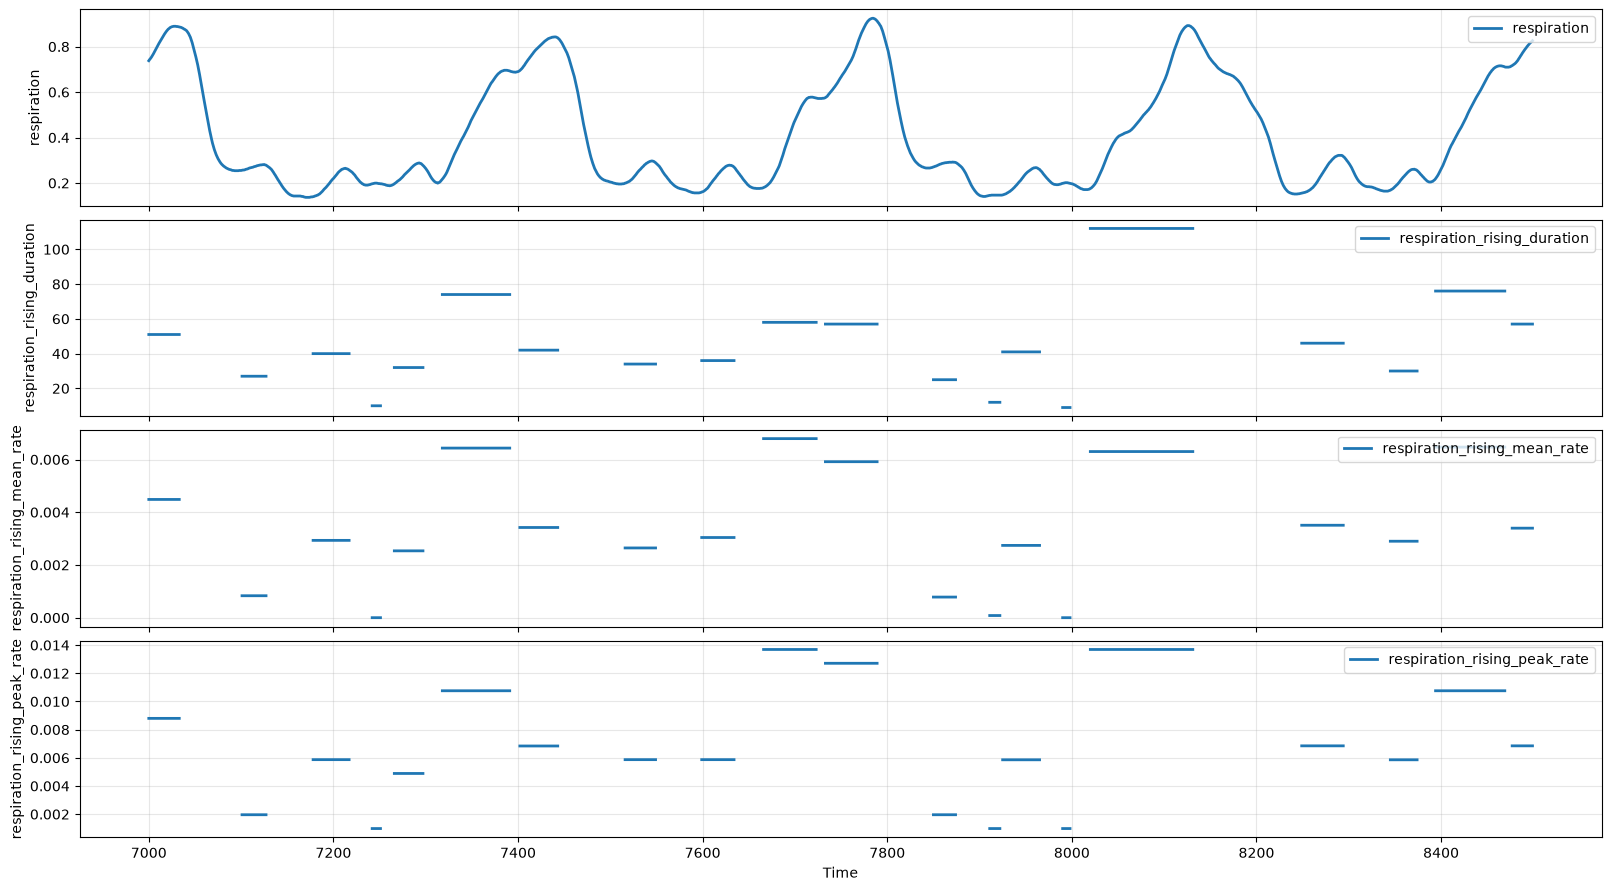

In [8]:
fg.plot(bidmc_features[7000:8500], [
    ['respiration'],
    ['respiration_rising_duration'],
    ['respiration_rising_mean_rate'],
    ['respiration_rising_peak_rate']
    ])